In [30]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


raw_data = 0

with h5py.File('../grace-7222025/raw data/grace-rawData-7222025-3.h5', 'r') as file:
    print("Keys in file: ", list(file.keys()))
    file_path = 'sessions/session_0/group_0/entry_0/result/frame'
    raw = file[file_path]
    print("Raw data:", raw)

    raw_data = np.array(raw)    

Keys in file:  ['client_info', 'generation', 'lib_version', 'server_info', 'session', 'sessions', 'timestamp', 'uuid']
Raw data: <HDF5 dataset "frame": shape (5881, 16, 8), type "|V4">


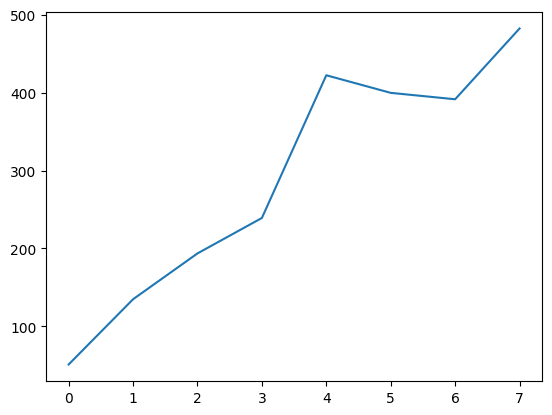

interactive(children=(IntSlider(value=0, description='Frame', max=5880), Output()), _dom_classes=('widget-inte…

In [ ]:
# print(raw_data.shape)
frames = raw_data.shape[0]
sweeps = raw_data.shape[1]
bins = raw_data.shape[2]
x = np.array(range(bins))

amps = np.zeros((frames,sweeps,bins))
phases = np.zeros((frames,sweeps,bins))

for frame in range(frames):
    for sweep in range(sweeps):
        for bin in range(bins):
            I = raw_data[frame][sweep][bin][0]
            Q = raw_data[frame][sweep][bin][1]
            iq_pair = complex(I,Q)

            amps[frame][sweep][bin] = abs(iq_pair)
            phases[frame][sweep][bin] = np.angle(iq_pair)



# fig, ax = plt.subplots()
# # line_1,line_2 = ax.plot(amps[0][0],'b', amps[0][1],'r')
# line_1, = ax.plot(amps[0][0])

# def update(frame):
#     line_1.set_ydata(amps[frame][0])
#     ax.relim()
#     ax.autoscale_view()
#     fig.canvas.draw()
#     return line_1
#     # fig.canvas.draw_idle()

# slider = widgets.IntSlider(min=0, max=frames-1, step=1, value=0, description='Frame')
# widgets.interact(update, frame=slider)

# plt.show()
